In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset

In [2]:
data = pd.read_csv("credit_card_transactions-ibm_v2.csv")

In [3]:
data.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


## Data Cleaning

In [4]:
data['Amount'] = data['Amount'].apply(lambda x: float(x[1:]))

In [5]:
data['Is Fraud?'] = data['Is Fraud?'].apply(lambda x: 0 if x == 'No' else 1)

## EDA

In [6]:
rows_to_drop = data.sample(n=int(data.shape[0]/50), random_state=42).index

short_data = data.drop(rows_to_drop)

* Average purchase amount for fraud purchase?
* Which year had the highest number of fraud purchases?
* Which city/state has most/least fraud purchases?
* Does a certain type of transaction cause more fraud?

#### Does a certain type of transaction cause more fraud?

In [7]:
grouped_fraud_by_chip = short_data[['Use Chip', 'Is Fraud?']].groupby('Use Chip').sum()

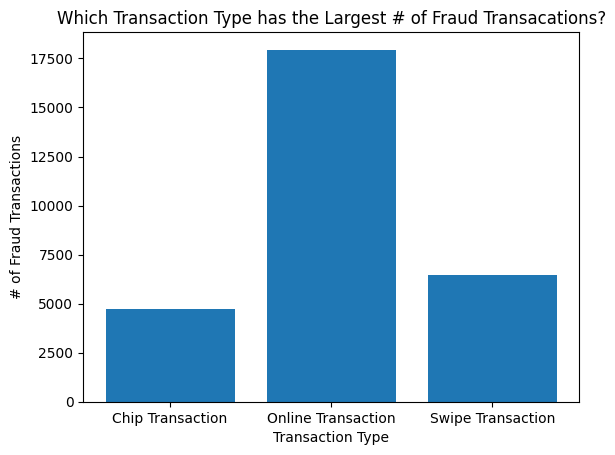

In [8]:
plt.bar(height=grouped_fraud_by_chip['Is Fraud?'], x=grouped_fraud_by_chip.index)
plt.xlabel('Transaction Type')
plt.ylabel('# of Fraud Transactions')
plt.title("Which Transaction Type has the Largest # of Fraud Transacations?")
plt.show()

#### Which country/US state has most/least fraud purchases?

In [9]:
state_fraud = short_data[['Merchant State', 'Is Fraud?']].groupby('Merchant State').sum().sort_values(by='Is Fraud?', ascending=False)[:10]

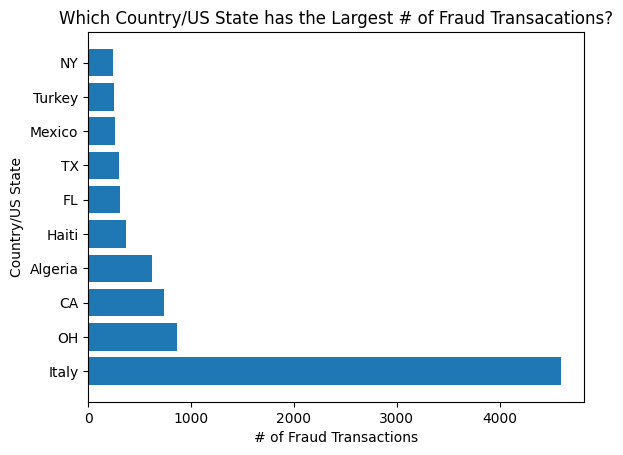

In [10]:
plt.barh(width=state_fraud['Is Fraud?'], y=state_fraud.index)
plt.xlabel('# of Fraud Transactions')
plt.ylabel('Country/US State')
plt.title("Which Country/US State has the Largest # of Fraud Transacations?")
plt.show()

#### Which year had the highest number of fraud purchases?

In [11]:
year_fraud = short_data[['Year','Is Fraud?']].groupby('Year').sum()

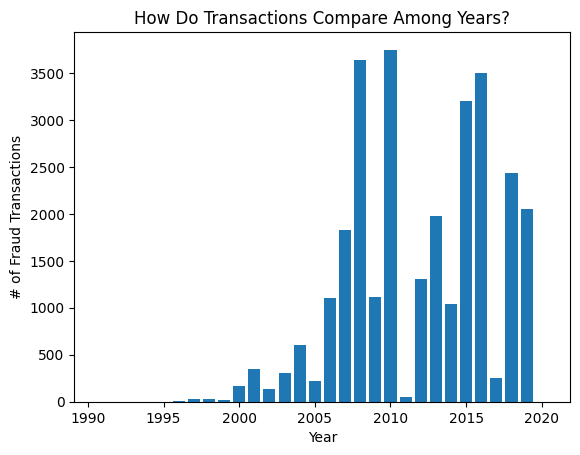

In [12]:
plt.bar(height=year_fraud['Is Fraud?'], x=year_fraud.index)
plt.ylabel('# of Fraud Transactions')
plt.xlabel('Year')
plt.title("How Do Transactions Compare Among Years?")
plt.show()

#### Average purchase amount for fraud purchase?

In [13]:
short_data[['Amount', 'Is Fraud?']].groupby('Is Fraud?').mean()

,Amount
Is Fraud?,
0,43.551140
1,108.705513


#### Distribution of purchase amounts

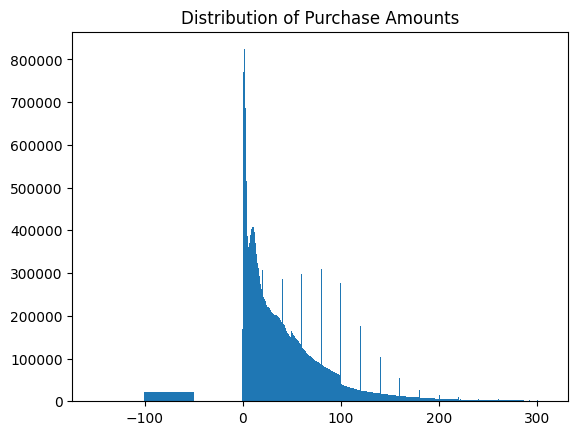

In [14]:
amount_col = short_data['Amount']
bins = np.arange(-150, 310) - 0.5
plt.hist(amount_col, bins=bins)
plt.title("Distribution of Purchase Amounts")
plt.show()

#### Fraud Transactions for Different MCC Values

In [15]:
mcc_fraud = short_data[['MCC', 'Is Fraud?']].groupby('MCC').sum().sort_values(by='Is Fraud?', ascending=False)[:10]

In [16]:
mcc_fraud

,Is Fraud?
MCC,
5311,4714
5300,2153
5310,2109
4829,1569
5912,1039
5411,920
5815,863
5651,841
5732,825


# Predictive Task

* Prediction Task:
    * Predict if a credit card transaction will be fraudulent based on features.
* How will we evaluate different models?
    * F1, ROC-AUC
* Baseline Models:
    * Logistic Regression -- Great efficient model that is highly interpretable. No need to standardize either. Drawbacks include that since it assumes a linear relationship between the features and prediction, it can't handle non-linear relationships or very complex data, without a lot of feature engineering.
    * Naive Bayes Model -- Model that is efficient and models high dimensional data very well. A drawback is that it assumes that features are conditionally independent. Another drawback is that it works better with categorial data. Another drawback is that if a feature in the test data isn't seen in the training data, then it automatically gets assigned to zero which can mess up our predictions.

# Model

* I plan to use an XGBoost Model
    * I am choosing this model because it is a strong ensemble version of decision trees that learns errors made from
    past trees. It can capture non-linear relationships without manual data transformations, it uses pruning and has built in regularization (lasso and ridge regression) tuning to prevent overfitting, and it has high computational efficiency. Especially for structured data it performs well. FEAUTRES?
* I am going to use OPTUNA, because it is the current industry standard for XGBoost. It features state-of-the-art algorithms (like TPE) to efficiently search the parameter space and includes aggressive pruning to automatically discard unpromising trials early.
* DID I ENCOUNTER ANY ISSUES/OVERFITTING?

# Literature

* Has your dataset/task been studied by others before?:
    * Yes, but not used in any big research papers, just used by regular people interested in finance/credit card data.
* How the dataset was used?
    *  The dataset had mainly just been used by regular people/students who like data to conduct some EDA or create a model like me.
* Are you working on a brand new task?
    * 
* How are other people attacking the same/similar tasks?
* What is state of the art method in this task or related tasks?
* Are your conclusions similar or different from existing work?
* What’s the major novelty of your work?

The dataset I am using in this project is the Credit Card Transactions dataset from Kaggle. This dataset contains millions of synthetic but realistic credit card transactions generated using an IBM multi-agent simulation framework. The primary task associated with this dataset is detecting fraudulent credit card transactions, which involves identifying whether a transaction is legitimate or fraudulent based on information such as transaction amount, merchant category, transaction type, location, and customer spending behavior.

This task has been studied extensively by researchers and finance practitioners for many years. Credit card fraud detection is one of the most important applications of machine learning in the financial sector because fraudulent transactions cahse significant financial losses for banks, businesses, and consumers. As electronic payments have become more common, the need for accurate and efficient fraud detection systems has continued to grow. Numerous academic studies, industry reports, and machine learning competitions have focused on developing models that can identify fraudulent transactions while minimizing false positives.

The dataset itself has been used for several different purposes. Most commonly, as mentioned before, it has been applied to fraud detection research, where the goal is to build classification models that distinguish fraudulent transactions from legitimate ones. Researchers have also used similar transaction datasets for anomaly detection, customer behavior analysis, transaction pattern mining, and evaluating the performance of machine learning and deep learning algorithms. Because this dataset contains realistic transaction attributes rather than heavily anonymized features, it provides opportunities to explore behavioral patterns in customers that may be difficult to study in more restricted datasets.

Although this project focuses on an important real-world problem, it is not a brand-new task. Fraud detection has been an active research area for decades, and many techniques have already been developed to address it. However, the availability of larger datasets, more advanced algorithms, and increased computational power has led researchers to continue to improve fraud detection systems. Therefore, while the overall task is well established, there is still room for improvement and innovatino in model design, feature engineering, explainability, and evaluation methods.

Researchers have approached fraud detection using various techniques. Traditional machine learning methods such as Logistic Regression, Decision Trees, Random Forests, Support Vector Machines (SVMs), and Naive Bayes have frequently been used as baseline models. More recently, ensemble learning methods such as XGBoost, LightGBM, and CatBoost have become popular since they are able to capture much more complex relationships within transaction data and often achieve very strong predictive performance at reasonable computational costs. In addition to these supervised learning methods, many researchers have explored anomaly detection approaches, including Isolation Forests, One-Class SVMs, and Autoencoders. These methods are mainly useful when fraudulent transactions are rare or when our labeled examples of fraud are limited.

Deep learning approaches have also grown in popularity. Models such as Long Short-Term Memory (LSTM) networks and Gated Recurrent Units (GRUs) can analyze sequences of transactions and learn temporal spending patterns for individual customers. More recently, transformer-based models designed for tabular and sequential data have shown promising results by capturing complex relationships between transactions and customer behaviors. These approaches require a lot of data, so they are especially useful when long transaction histories are available.

Currently, there is no single method that is universally considered the "best" for all fraud detection problems. However, gradient boosting methods such as XGBoost are often regarded as among the strongest practical solutions due to their combination of high accuracy, efficiency, and interpretability. At the same time, transformer-based architectures and advanced deep learning models are becoming increasingly competitive, particularly for large datasets with rich temporal information. However, it is difficult to find such rich datasets. In many cases, the best-performing systems have found a combination of sophisticated feature engineering with ensemble or deep learning methods to achieve optimal results.

**The conclusions of this project align with existing research. Since the ensemble methods that we used, including XGBoost or Random Forest, outperformed the simpler models, the results are consistent with much of the current fraud detection literature. Similarly, since deep learning models demonstrate strong performance by leveraging transaction sequences and customer behavior patterns, this would also agree with recent findings in the field. Therefore, the overall conclusions are likely to reinforce existing evidence that advanced machine learning techniques are highly effective for fraud detection when combined with appropriate feature engineering and class imbalance handling.**

**The major novelty of this work comes from two primary contributions. First, this project provides a comprehensive comparison of multiple machine learning algorithms on our transaction dataset. Rather than focusing on a single model, the project evaluates and compares different approaches to better understand their strengths and weaknesses within the fraud detection domain. Second, the project emphasizes explainable fraud detection by examining which features contribute most strongly to fraud predictions. Understanding why a transaction is classified as fraudulent can be equally valuable for financial institutions, auditors, and customers. By combining model comparison with interpretability, the project contributes both practical insights and a deeper understanding of fraud detection mechanisms.**

Overall, this work builds upon a well-established research area while leveraging a modern, large-scale dataset to evaluate current machine learning approaches. Although fraud detection is not a new task, the combination of comparative model analysis and explainable prediction techniques provides meaningful contributions that can help improve the effectiveness and transparency of an important problem in fraud detection systems.


# Model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [24]:
# load data
df = short_data.copy()
y = df['Is Fraud?']

In [25]:
# feature engineering
# create datetime
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str)
)

# hour feature
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M"
).dt.hour

# day of week
df["DayOfWeek"] = df["Date"].dt.dayofweek

# log amount
df["LogAmount"] = np.log1p(df["Amount"])

# error flag
df["HasError"] = df["Errors?"].notna().astype(int)

# merchant frequency
merchant_freq = df["Merchant Name"].value_counts()
df["MerchantFreq"] = (
    df["Merchant Name"]
    .map(merchant_freq)
)

# user transaction count
user_freq = df["User"].value_counts()

df["UserTxnCount"] = (
    df["User"]
    .map(user_freq)
)

/Users/jonathanyepez/miniforge3/envs/dsc140b/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonathanyepez/miniforge3/envs/dsc140b/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [26]:
# extra data cleaning
# replace infinite values with nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# convert ints to strings for categorical number values
df["Merchant Name"] = df["Merchant Name"].astype(str)
df["User"] = df["User"].astype(str)
df["Card"] = df["Card"].astype(str)
df["MCC"] = df["MCC"].astype(str)

## Baseline Models

### Linear Regression Baseline Model

In [27]:
# prep df
lin_reg_df = df.copy()

# Convert Time -> hour/minute
lin_reg_df["HourFromTime"] = pd.to_datetime(
    lin_reg_df["Time"],
    format="%H:%M"
).dt.hour

lin_reg_df["MinuteFromTime"] = pd.to_datetime(
    lin_reg_df["Time"],
    format="%H:%M"
).dt.minute


lin_reg_df = lin_reg_df.drop(columns=["Time", "Date"])

# target
y = lin_reg_df["Is Fraud?"]
X = lin_reg_df.drop(columns=["Is Fraud?"])

# drop high-cardinality IDs for baseline
drop_cols = [
    "User",
    "Card",
    "Merchant Name"
]

X = X.drop(columns=drop_cols)

# split up feature types

categorical_features = [
    "Use Chip",
    "Merchant City",
    "Merchant State",
    "Errors?"
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

# preprocessing

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# linear regression baseline model

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

# continous predictions
y_pred_continuous = model.predict(X_test)

# Convert to class labels
y_pred = (y_pred_continuous >= 0.5).astype(int)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_continuous))

Accuracy: 0.9987811289641291
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.7249376124764623


In [28]:
f1_score(y_test, y_pred, average='weighted')

0.9981720650843335

### Logistic Regression Baseline Model

In [21]:
# drop target and raw date fields
X = df.drop(
    columns=[
        "Is Fraud?",
        "Date"
    ]
)

In [22]:
# define numeric and categorical features
numeric_features = [
    "Amount",
    "LogAmount",
    "Hour",
    "DayOfWeek",
    "Zip",
    "MerchantFreq",
    "UserTxnCount"
]

categorical_features = [
    "User",
    "Card",
    "Use Chip",
    "Merchant Name",
    "Merchant City",
    "Merchant State",
    "MCC",
    "Errors?"
]

In [23]:
# preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num",
     numeric_transformer,
     numeric_features),

    ("cat",
     categorical_transformer,
     categorical_features)
])

In [24]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# LOGISTIC REGRESSION MODEL
# build model
logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         max_iter=1000,
         class_weight="balanced"
     ))
])

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:,1]

# evaluation
print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

KeyboardInterrupt: 

# True Model - XGBoost

In [29]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

In [31]:
xg_df = df.copy()

In [32]:
xg_df.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,MCC,Errors?,Is Fraud?,Date,Hour,DayOfWeek,LogAmount,HasError,MerchantFreq,UserTxnCount
0,0,0,2002,9,1,06:21,134.09,Swipe Transaction,3527213246127876953,La Verne,...,5300,NaN,0,2002-09-01,6,6,4.905941,0,1543,19567
1,0,0,2002,9,1,06:42,38.48,Swipe Transaction,-727612092139916043,Monterey Park,...,5411,NaN,0,2002-09-01,6,6,3.675794,0,119889,19567
2,0,0,2002,9,2,06:22,120.34,Swipe Transaction,-727612092139916043,Monterey Park,...,5411,NaN,0,2002-09-02,6,0,4.798597,0,119889,19567
3,0,0,2002,9,2,17:45,128.95,Swipe Transaction,3414527459579106770,Monterey Park,...,5651,NaN,0,2002-09-02,17,0,4.867150,0,20608,19567
4,0,0,2002,9,3,06:23,104.71,Swipe Transaction,5817218446178736267,La Verne,...,5912,NaN,0,2002-09-03,6,1,4.660699,0,186102,19567


In [33]:
# load data
# target
y = xg_df["Is Fraud?"]

# drop target and unnecessary columns
X = xg_df.drop(columns=[
    "Is Fraud?",
    "Date",      # already extracted useful components
    "Time"       # Hour already exists
])

### XGBoost Model

In [ ]:
# feature types
categorical_features = [
    "Use Chip",
    "Merchant City",
    "Merchant State",
    "Errors?"
]

numeric_features = [
    "User",
    "Card",
    "Year",
    "Month",
    "Day",
    "Amount",
    "Merchant Name",
    "Zip",
    "MCC",
    "Hour",
    "DayOfWeek",
    "LogAmount",
    "HasError",
    "MerchantFreq",
    "UserTxnCount"
]

# Keep only columns that actually exist
categorical_features = [
    c for c in categorical_features if c in X.columns
]

numeric_features = [
    c for c in numeric_features if c in X.columns
]

# preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# class imbalance weight
fraud_count = y_train.sum()
nonfraud_count = len(y_train) - fraud_count

scale_pos_weight = nonfraud_count / fraud_count

# XGBoost model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

# parameter distributions
param_dist = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__reg_alpha": [0, 0.01, 0.1, 1],
    "classifier__reg_lambda": [1, 2, 5, 10]
}

# randomized search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=25,          # number of parameter combinations to try
    scoring="roc_auc",
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

# fit search
random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

# best model
best_model = random_search.best_estimator_

# predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# evaluation
print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=4, classifier__n_estimators=300, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=14.8min


/Users/jonathanyepez/miniforge3/envs/dsc140b/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=4, classifier__n_estimators=300, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=15.8min
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=4, classifier__n_estimators=300, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=14.8min


### Ablation Experiment

In [53]:
from sklearn.metrics import (
    f1_score,
    roc_auc_score
)

def run_xgb_ablation(X, y, remove_features=None):

    if remove_features is None:
        remove_features = []

    # Remove selected features
    X_temp = X.drop(
        columns=[c for c in remove_features if c in X.columns]
    )

    # Feature lists
    categorical = [
        "Use Chip",
        "Merchant City",
        "Merchant State",
        "Errors?"
    ]

    numeric = [
        "User",
        "Card",
        "Year",
        "Month",
        "Day",
        "Amount",
        "Merchant Name",
        "Zip",
        "MCC",
        "Hour",
        "DayOfWeek",
        "LogAmount",
        "HasError",
        "MerchantFreq",
        "UserTxnCount"
    ]

    categorical = [
        c for c in categorical
        if c in X_temp.columns
    ]

    numeric = [
        c for c in numeric
        if c in X_temp.columns
    ]

    preprocessor = ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer",
                 SimpleImputer(strategy="median"))
            ]),
            numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer",
                 SimpleImputer(strategy="most_frequent")),
                ("onehot",
                 OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        )
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    fraud_count = y_train.sum()
    nonfraud_count = len(y_train) - fraud_count

    scale_pos_weight = nonfraud_count / fraud_count

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",
         xgb.XGBClassifier(
             n_estimators=500,
             max_depth=8,
             learning_rate=0.05,
             subsample=0.8,
             colsample_bytree=0.8,
             scale_pos_weight=scale_pos_weight,
             eval_metric="logloss",
             random_state=42,
             n_jobs=-1
         ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    fraud_f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    return fraud_f1, roc_auc

In [54]:
ablations = {
    "Full Model": [],

    "No Amount":
        ["Amount", "LogAmount"],

    "No Transaction Type":
        ["Use Chip"],

    "No Location":
        ["Merchant City",
         "Merchant State",
         "Zip"],

    "No Merchant Info":
        ["Merchant Name",
         "MCC"],

    "No Error Features":
        ["Errors?",
         "HasError"],

    "No Behavioral Features":
        ["MerchantFreq",
         "UserTxnCount"]
}

results = []

for name, features in ablations.items():

    fraud_f1, roc_auc = run_xgb_ablation(
        X,
        y,
        remove_features=features
    )

    results.append([
        name,
        fraud_f1,
        roc_auc
    ])

In [55]:
import pandas as pd

In [56]:
ablation_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Fraud F1",
        "ROC-AUC"
    ]
)

print(ablation_df.sort_values(
    "Fraud F1",
    ascending=False
))

                    Model  Fraud F1   ROC-AUC
5       No Error Features  0.140468  0.997574
0              Full Model  0.138306  0.997505
2     No Transaction Type  0.137427  0.997561
3             No Location  0.117047  0.994968
6  No Behavioral Features  0.112675  0.996556
1               No Amount  0.111768  0.996866
4        No Merchant Info  0.088273  0.995656


In [58]:
ablation_df.to_csv("ablation_df.csv", index=False)